### Objective

A Comparison between regression Models' ability to learn and predict people's $(X,Y)$ positions/ Euclidean Distance based on bounding box area as captured by the smartspace sensors complex.

### The Data

Annotated dataset for multi-camera tracking and 2D/3D object detection.

- **Data Source:**  
  [NVIDIA PhysicalAI SmartSpaces Dataset (Hugging Face)](https://huggingface.co/datasets/nvidia/PhysicalAI-SmartSpaces)

- **Data Description:**  
  - Consists of videos from indoor scenes (warehouses, hospitals, retail spaces).
  - Time-synchronized to track humans and robots across multiple cameras.
  - For this project, we use the **calibration** and **ground truth annotation** files from a 5-minute simulation.
  - Each frame captures:
    - Bounding boxes of each object in each camera view.
    - Pixel area (feature) and Euclidean distance from the origin (target).
  - The training dataset contains **14 different warehouses**, each with:
    - A varying number of cameras.
    - A varying number of moving units (Humans/Robots).

### Predictors and Response
The dataset's starting point the the calculated bounding-box area of a person as captured by the sensor's POV, if the person is out of the sensor's POV, then the bounding-box area equals zero.

- Input Features: **Bounding-Box Area vector of all sensors within the smart space**

- Targets: 
  - **#1: The Persons' X Position**
  - **#2: The Persons' Y Position**
  - **#3: The Persons' Euclidean Distance from origin, where:**
  $$
  \text{Euclidean Distance} = \sqrt{\text{X position}^2 + \text{Y position}^2}
  $$
### Models
  - Polynomial Regression
  - Genral Additive Model
  - Support Vector Machine
  - Random Forest
  - Gradient Boosting Machine
  - Extreme Gradient Boosting (XGBoost)
  - Multi Layer percepetron (Dense Neural Network)

### Performance Metrics
All models are compared and benchmarked against each other on the following metrics:
  - **Mean Squared Error (MSE)**: Penalizes larger errors more heavily by squaring the differences between predicted and actual values.
  $$
  \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
  $$
  - **Root Mean Squared Error (RMSE)**: Square root of MSE; retains original units and is more interpretable.
  $$
  \text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
  $$
  - **Mean Absolute Error (MAE)**: Average of absolute differences; treats all errors equally.
  $$
  \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
  $$
  - **Coefficient of Determination ($R^2$)**: Measures the proportion of variance explained by the model; closer to 1 indicates better fit.
  $$
  R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
  $$
  - **Residual plots and diagnostics**, including:
    - **Residual Histogram**: Visualizes the distribution of residuals to check for normality or skewness.
    - **Q-Q plot**: Plots quantiles of residuals against a normal distribution; deviations from the line indicate non-normality.
    - **Predicted vs. Actual Scatter**: Compares predicted values to actual ones; closer clustering around the diagonal indicates better model performance.
    - **Shapiro-Wilk test**: Statistical test for residual normality.

In [ ]:
#%% Data Fetching and initial data description
import pandas as pd
from IPython.display import display
from src.config import PROCESSED_DATA_DIR
from src.regression_utils import *

# ---------------------------------------------
# Warehouse_000_bounding_box_areas # Shape = (1471, 56)
# Warehouse_002_bounding_box_areas # Shape = (1273, 51)
# Warehouse_006_bounding_box_areas # Shape = (1801, 15)
# Warehouse_007_bounding_box_areas # Shape = (2199, 17)
# Warehouse_009_bounding_box_areas # Shape = (1571, 16)

csv_path = PROCESSED_DATA_DIR / "Warehouse_006_bounding_box_areas.csv"
# ---------------------------------------------

df = pd.read_csv(csv_path)
feature_columns = [col for col in df.columns if 'Camera' in col]
unit_ids = df.unit_id.unique().tolist()

display(df.head(20))
print(f'Cameras in the warehouse: {len(feature_columns)}')
display(df.columns)
print(f'Number of persons in the warehouse: {len(df.unit_id.unique())}')

,Camera_0000,Camera_0001,Camera_0002,Camera_0003,Camera_0004,Camera_0005,Camera_0006,Camera_0007,Camera_0008,Camera_0009,x_position,y_position,z_position,unit_distance_from_origin,unit_id
0,26520,0,0,11322,0,0,0,316334,0,0,2.589343,10.800000,1.075566,11,281
1,0,0,0,0,936,0,0,0,6720,567,-18.011159,26.403460,0.314779,31,40
2,0,0,0,330,1260,0,0,0,6930,525,-18.004587,26.456678,0.314769,32,40
3,0,0,0,253,1110,0,0,0,9632,616,-17.583439,25.530681,0.314813,30,40
4,0,0,0,0,0,0,0,0,14700,0,-14.930130,26.016224,0.314820,29,40
5,0,0,0,0,2356,0,0,0,0,0,-14.358623,25.185150,0.314787,28,40
6,0,0,0,0,5220,0,0,0,0,0,-8.207934,26.763396,0.314786,27,40
7,0,0,0,0,5244,0,0,0,0,0,-8.251649,25.708052,0.314796,26,40
8,0,0,0,0,4256,0,0,0,0,0,-8.306384,24.636311,0.314783,25,40
9,0,0,0,0,4116,0,0,0,0,0,-8.354691,23.560619,0.314786,24,40


Cameras in the warehouse: 10


Index(['Camera_0000', 'Camera_0001', 'Camera_0002', 'Camera_0003',
       'Camera_0004', 'Camera_0005', 'Camera_0006', 'Camera_0007',
       'Camera_0008', 'Camera_0009', 'x_position', 'y_position', 'z_position',
       'unit_distance_from_origin', 'unit_id'],
      dtype='object')

Number of persons in the warehouse: 106


### Shapiro-Wilk Normality Test for Residuals

The Shapiro-Wilk test evaluates whether residuals follow a normal distribution, an assumption underlying many regression inference methods.

- **Null hypothesis ($H_0$):** Residuals are drawn from a normal distribution.  
$$
W = \frac{\left(\sum_{i=1}^n a_i x_{(i)}\right)^2}{\sum_{i=1}^n (x_i - \bar{x})^2}
$$

- $x_{(i)}$: ordered sample values (residuals)  
- $a_i$: constants derived from expected values of order statistics of a normal distribution  
- $\bar{x}$: sample mean  


In [2]:
# Available IDs for plugging into interactive data visualization cell

print(f"{'='*40}")
print("Available Unit IDs:")
print(", ".join(str(uid) for uid in unit_ids)) 
print(f"{'='*40}\n")

print(f"{'='*40}")
print("Available Sensor (Camera) IDs:")
print(", ".join(str(i) for i in range(len(feature_columns))))
print(f"{'='*40}\n")

Available Unit IDs:
281, 40, 365, 366, 395, 205, 341, 364, 7, 8, 311, 218, 358, 355, 35, 21, 359, 1, 352, 207, 29, 362, 386, 4, 6, 10, 345, 34, 219, 216, 387, 404, 340, 18, 354, 24, 356, 31, 39, 342, 393, 361, 213, 37, 388, 27, 12, 20, 343, 210, 3, 217, 16, 211, 14, 351, 208, 348, 283, 32, 357, 15, 389, 22, 30, 206, 0, 215, 212, 349, 214, 9, 347, 5, 312, 390, 209, 391, 19, 346, 338, 17, 25, 337, 26, 353, 23, 360, 394, 392, 220, 363, 11, 36, 33, 350, 2, 13, 336, 28, 38, 282, 339, 344, 418, 419

Available Sensor (Camera) IDs:
0, 1, 2, 3, 4, 5, 6, 7, 8, 9



The X & Y positions of person #366 trajectory, as well as the Euclidean distance from origin (center of map):


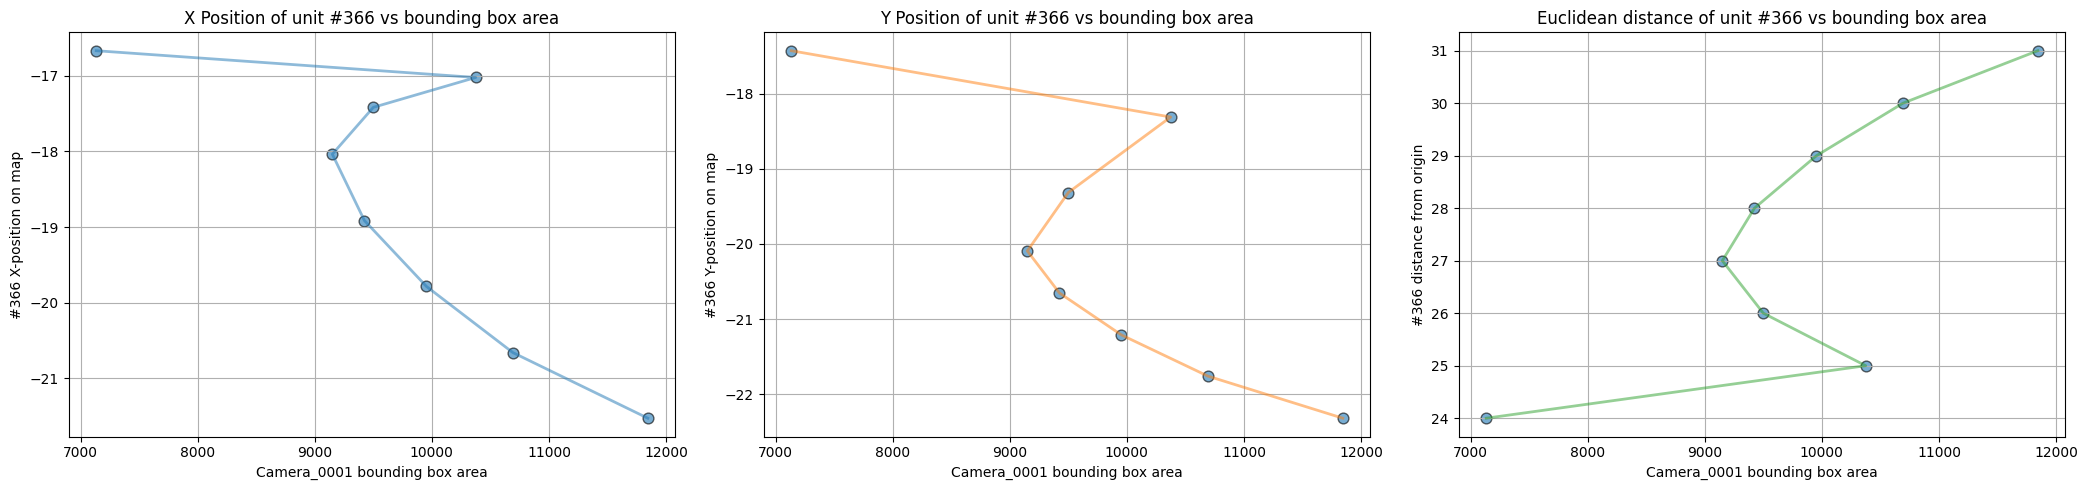

Scatter plot and histogram of camera Camera_0001:


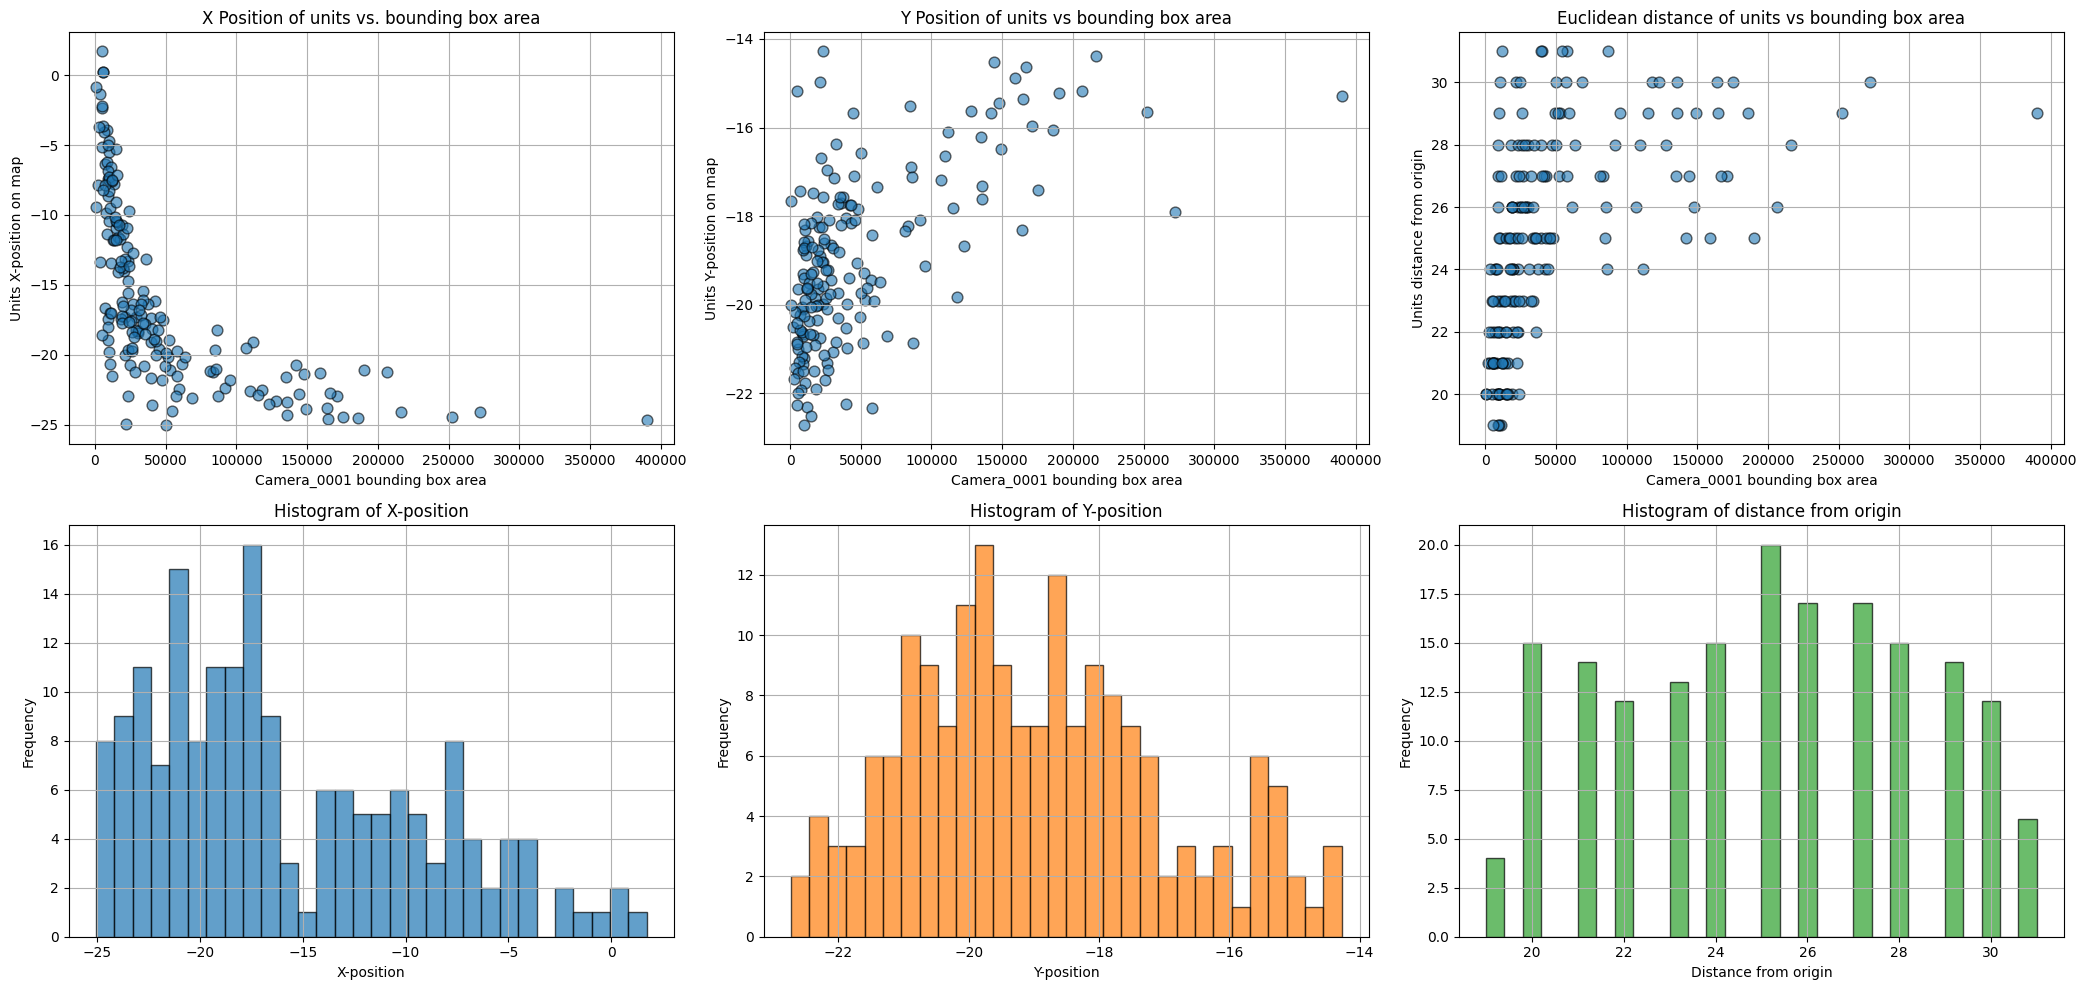

In [5]:
# Data Visualization
# --------------------------------------------------------------
unit_id = 3        
sensor_id = 1
# --------------------------------------------------------------
print(f'The X & Y positions of person #{unit_ids[unit_id]} trajectory, as well as the Euclidean distance from origin (center of map):')
plot_unit_distance_vs_sensor_area(bounding_area_df=df.copy(), 
                                  unit_id=unit_ids[unit_id], 
                                  camera_id=feature_columns[sensor_id],
                                  feature_columns = feature_columns)
print('='* 100)
print(f'Scatter plot and histogram of camera {feature_columns[sensor_id]}:')
sensor_distance_scatter(bounding_area_df=df.copy(), 
                        camera_id=feature_columns[sensor_id],
                        feature_columns = feature_columns)

In [6]:
# Data train-test stratified split
from sklearn.model_selection import train_test_split

# --------------------------------------------------------------
random_state = 42
train_test_split_ratio = 0.2
# --------------------------------------------------------------

X = df[feature_columns].values

y_all = np.column_stack([
    df['x_position'].values,
    df['y_position'].values,
    df['unit_distance_from_origin'].values
])

X_train, X_test, y_train_all, y_test_all = train_test_split(X, y_all, test_size=train_test_split_ratio, random_state=random_state)

y_train_x = y_train_all[:, 0]
y_train_y = y_train_all[:, 1]
y_train_euc = y_train_all[:, 2]

y_test_x = y_test_all[:, 0]
y_test_y = y_test_all[:, 1]
y_test_euc = y_test_all[:, 2]

targets = {
    'x_position': [y_train_x, y_test_x],
    'y_position': [y_train_y, y_test_y],
    'euclidean_distance': [y_train_euc, y_test_euc]
}

### Polynomial Regression

Polynomial regression fits a linear model to nonlinear relationships by including polynomial terms of the predictor:

$$
\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_n x^n
$$


x_position - Degree 1, CV R²: -0.1486
x_position - Degree 2, CV R²: -37.2465
x_position - Degree 3, CV R²: -949.7772

Evaluation for x_position:
Test MSE: 30.472937873375393
Test MAE: 4.403728888286188
Test R2: 0.44739432396318635

y_position - Degree 1, CV R²: 0.2009
y_position - Degree 2, CV R²: -94.2983
y_position - Degree 3, CV R²: -23188.4834

Evaluation for y_position:
Test MSE: 103.60777346228657
Test MAE: 8.06254726252186
Test R2: 0.5007538389903727

euclidean_distance - Degree 1, CV R²: 0.3045
euclidean_distance - Degree 2, CV R²: -75.5359
euclidean_distance - Degree 3, CV R²: -31301.0597

Evaluation for euclidean_distance:
Test MSE: 46.85759584792071
Test MAE: 5.461195511300809
Test R2: 0.3169878631560755


Best polynomial degrees per target: {'x_position': 1, 'y_position': 1, 'euclidean_distance': 1}


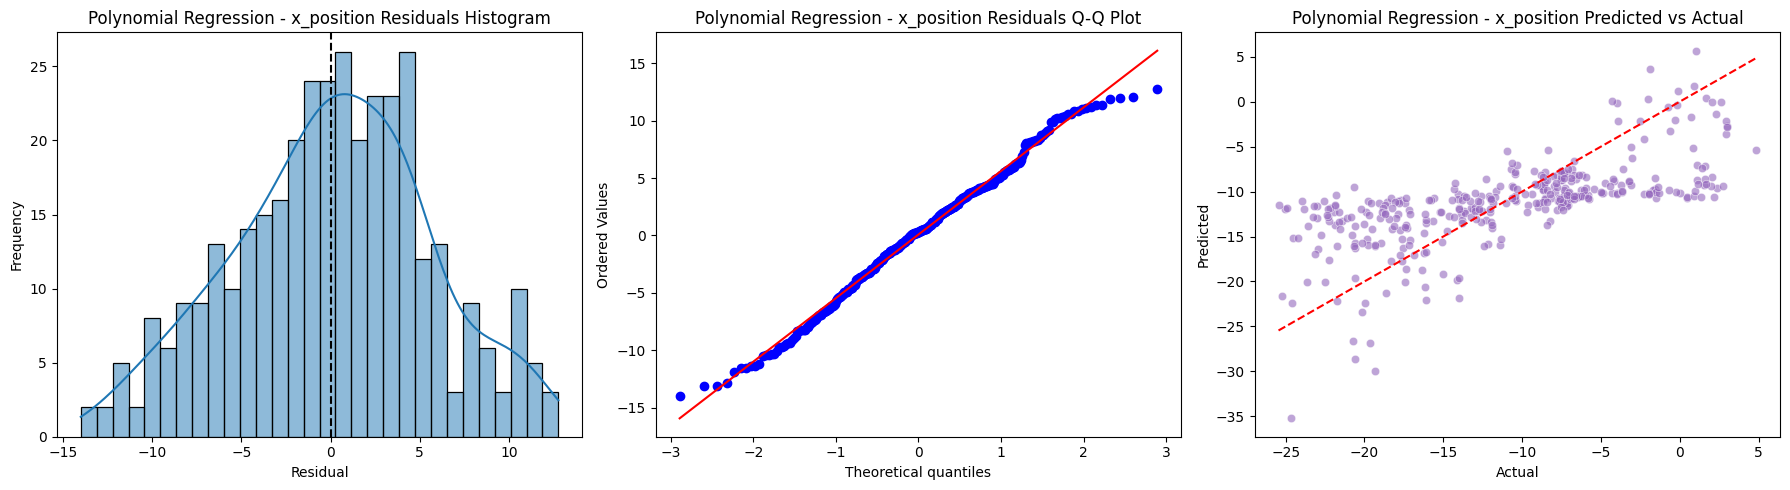

        Model: Polynomial Regression - x_position
MSE: 30.4729 (95% CI: [-27.4642, -5.8489])
RMSE: 5.5202
MAE: 4.4037
R^2: 0.4474
Residual Mean: 0.0843, Residual Std: 5.5196
Shapiro-Wilk Test p-value: 0.0535 (normality not rejected)


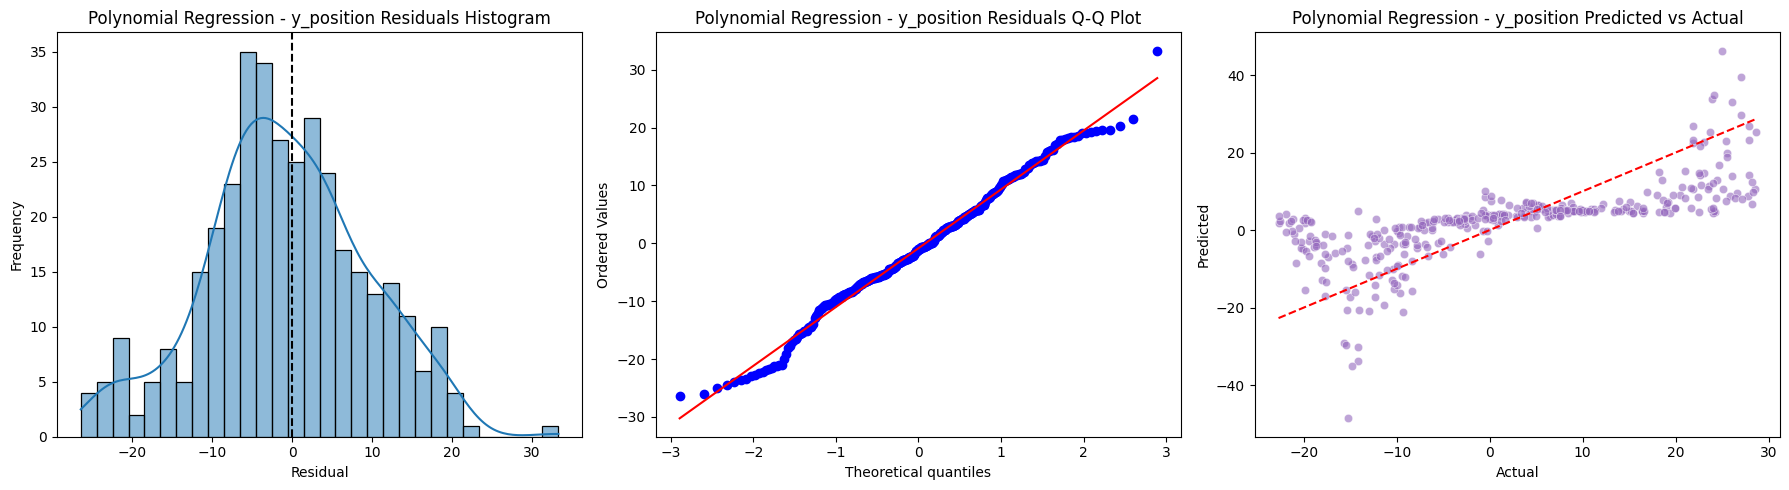

        Model: Polynomial Regression - y_position
MSE: 103.6078 (95% CI: [-150.8992, -60.3490])
RMSE: 10.1788
MAE: 8.0625
R^2: 0.5008
Residual Mean: -0.8462, Residual Std: 10.1436
Shapiro-Wilk Test p-value: 0.0383 (normality rejected)


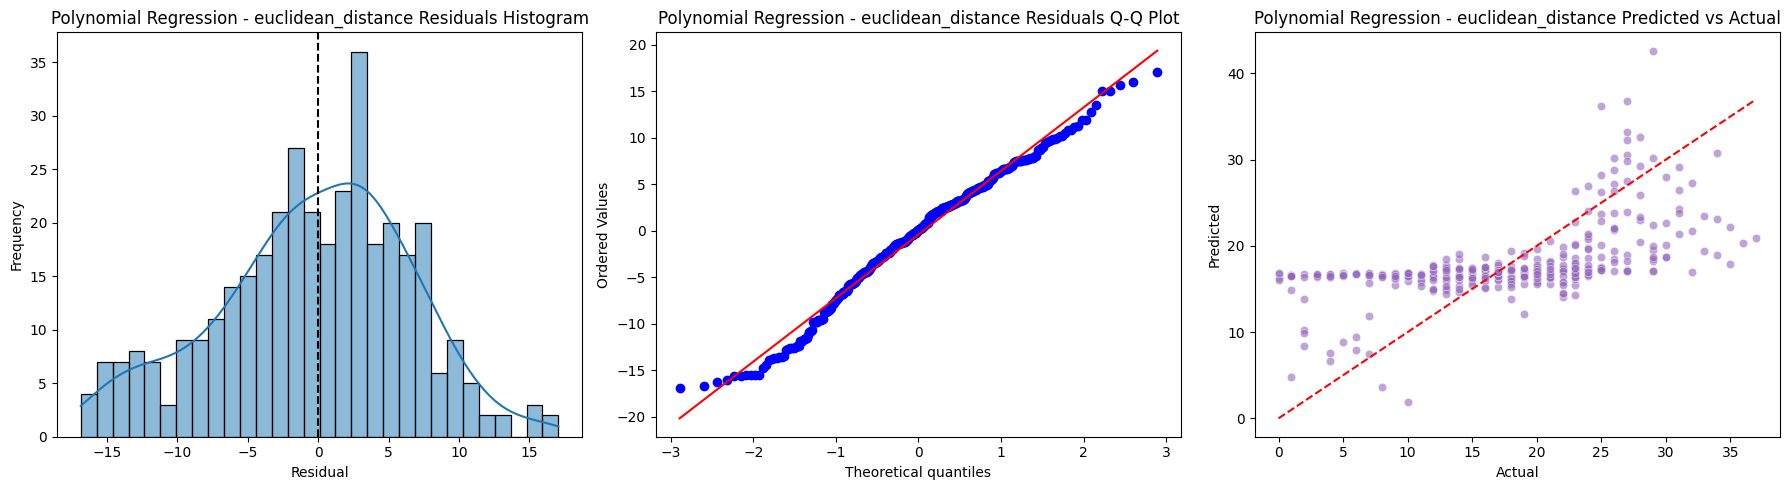

        Model: Polynomial Regression - euclidean_distance
MSE: 46.8576 (95% CI: [-6.9423, 17.6935])
RMSE: 6.8453
MAE: 5.4612
R^2: 0.3170
Residual Mean: -0.3813, Residual Std: 6.8346
Shapiro-Wilk Test p-value: 0.0011 (normality rejected)


In [7]:
# Polynomial Regression
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures

poly_models = {}
poly_preds = {}
poly_best_degrees = {}

for target_name, (y_train_target, y_test_target) in targets.items():
    best_score = -np.inf
    best_deg = 1

    for deg in range(1, 4):
        pipe = make_pipeline(
            StandardScaler(),
            PolynomialFeatures(degree=deg, include_bias=False),
            RidgeCV(alphas=np.logspace(-3, 3, 10), cv=5)
        )
        scores = cross_val_score(pipe, X_train, y_train_target, cv=3, scoring='r2')
        mean_score = np.mean(scores)
        print(f"{target_name} - Degree {deg}, CV R²: {mean_score:.4f}")
        if mean_score > best_score:
            best_score = mean_score
            best_deg = deg

    poly_best_degrees[target_name] = best_deg

    # Final model
    final_pipe = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=best_deg, include_bias=False),
        RidgeCV(alphas=np.logspace(-3, 3, 10), cv=5)
    )
    final_pipe.fit(X_train, y_train_target)
    poly_models[target_name] = final_pipe

    # Predict and evaluate
    y_pred = final_pipe.predict(X_test)
    poly_preds[target_name] = (y_test_target, y_pred)

    print(f"\nEvaluation for {target_name}:")
    print('=' * 30)
    print("Test MSE:", mean_squared_error(y_test_target, y_pred))
    print("Test MAE:", mean_absolute_error(y_test_target, y_pred))
    print("Test R2:", r2_score(y_test_target, y_pred))
    print('=' * 30)
    print()

print("\nBest polynomial degrees per target:", poly_best_degrees)

for target_name, (y_train_target, y_test_target) in targets.items():
    model_analytics(poly_preds[target_name][0], poly_preds[target_name][1], 'Polynomial Regression - ' + target_name)


### Generalized Additive Models (GAMs)

GAMs model the response as a sum of smooth functions of predictors:

$$
g(\mathbb{E}[Y]) = \beta_0 + f_1(X_1) + f_2(X_2) + \cdots + f_p(X_p)
$$

- $g$ is a link function.  
- Each $f_j$ is a smooth function.  

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:02
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:02
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:02
 36% (4 of 11) |#########                | Elapsed Time: 0:00:01 ETA:   0:00:01
 45% (5 of 11) |###########              | Elapsed Time: 0:00:01 ETA:   0:00:01
 54% (6 of 11) |#############            | Elapsed Time: 0:00:01 ETA:   0:00:01
 63% (7 of 11) |###############          | Elapsed Time: 0:00:01 ETA:   0:00:01
 72% (8 of 11) |##################       | Elapsed Time: 0:00:02 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:02 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:02 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:02 Time:  0:00:02
  0% (0 of 11) |                        


GAM Evaluation for x_position:
Test MSE: 16.11598713274134
Test MAE: 3.1226459263813338
Test R2: 0.7077477071132606



  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:02
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:02
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:02
 36% (4 of 11) |#########                | Elapsed Time: 0:00:01 ETA:   0:00:02
 45% (5 of 11) |###########              | Elapsed Time: 0:00:01 ETA:   0:00:01
 54% (6 of 11) |#############            | Elapsed Time: 0:00:01 ETA:   0:00:01
 63% (7 of 11) |###############          | Elapsed Time: 0:00:02 ETA:   0:00:01
 72% (8 of 11) |##################       | Elapsed Time: 0:00:02 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:02 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:02 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:03 Time:  0:00:03
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--



GAM Evaluation for y_position:
Test MSE: 33.35218993843005
Test MAE: 4.08540300061318
Test R2: 0.839288576217825



  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:02
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:02
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:02
 36% (4 of 11) |#########                | Elapsed Time: 0:00:01 ETA:   0:00:01
 45% (5 of 11) |###########              | Elapsed Time: 0:00:01 ETA:   0:00:01
 54% (6 of 11) |#############            | Elapsed Time: 0:00:01 ETA:   0:00:01
 63% (7 of 11) |###############          | Elapsed Time: 0:00:01 ETA:   0:00:01
 72% (8 of 11) |##################       | Elapsed Time: 0:00:02 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:02 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:02 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:03 Time:  0:00:03



GAM Evaluation for euclidean_distance:
Test MSE: 17.828066767353167
Test MAE: 3.3384943615237113
Test R2: 0.7401320798001124



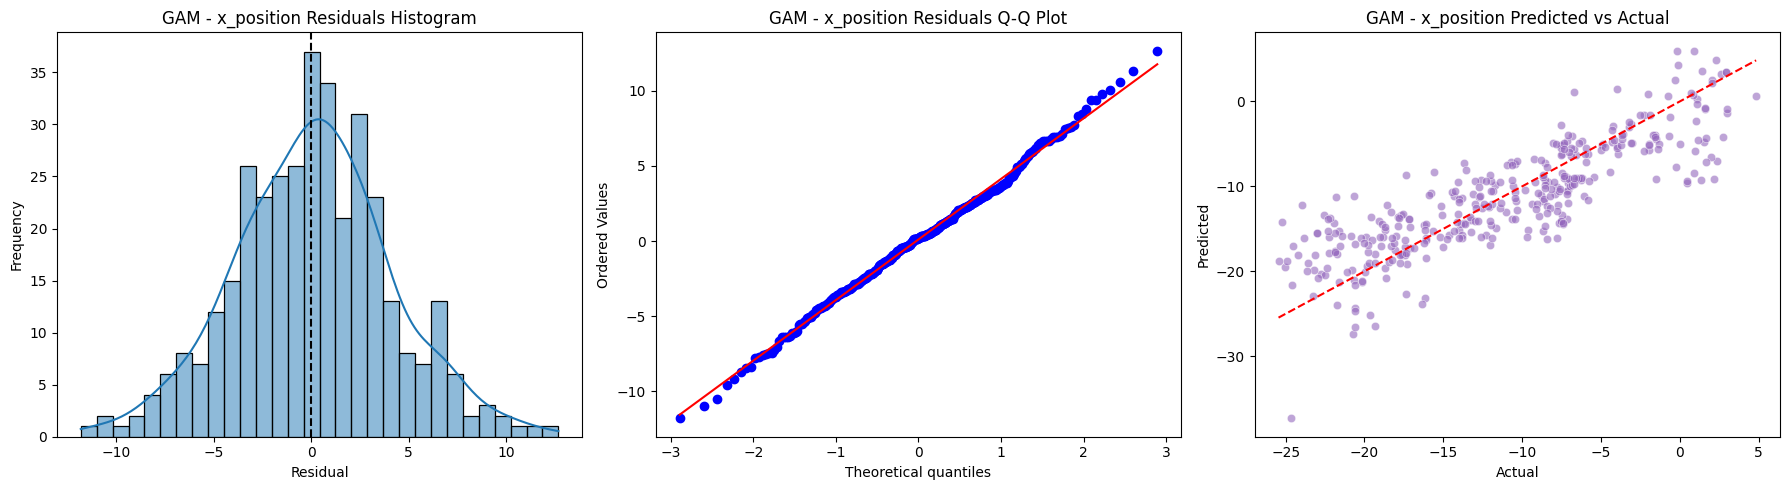

        Model: GAM - x_position
MSE: 16.1160 (95% CI: [-77.7132, -51.5244])
RMSE: 4.0145
MAE: 3.1226
R^2: 0.7077
Residual Mean: 0.1038, Residual Std: 4.0131
Shapiro-Wilk Test p-value: 0.6644 (normality not rejected)


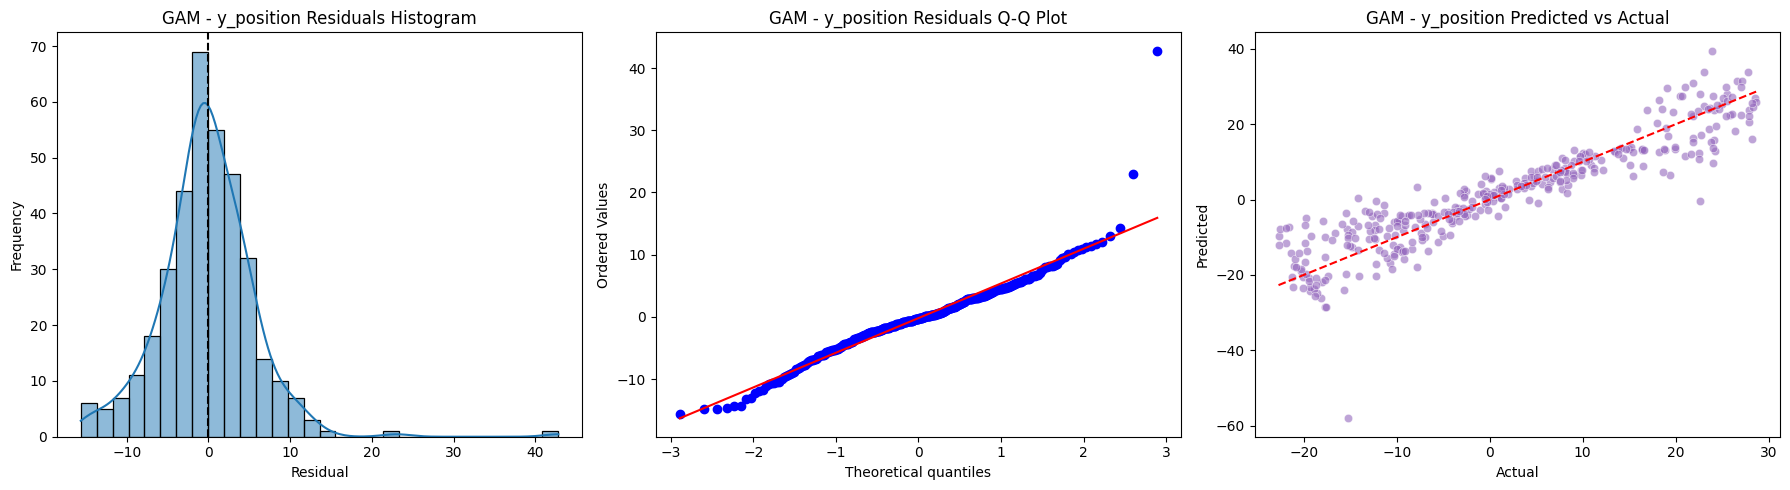

        Model: GAM - y_position
MSE: 33.3522 (95% CI: [-390.4957, -285.2806])
RMSE: 5.7751
MAE: 4.0854
R^2: 0.8393
Residual Mean: -0.2049, Residual Std: 5.7715
Shapiro-Wilk Test p-value: 0.0000 (normality rejected)


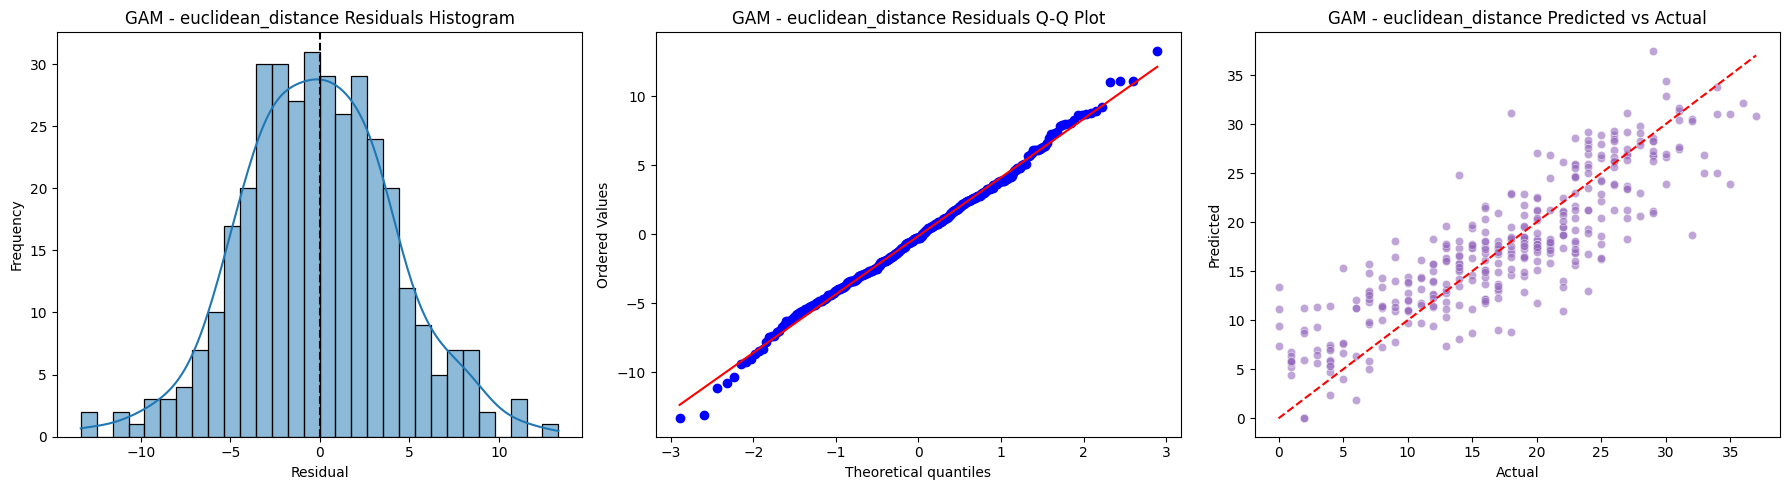

        Model: GAM - euclidean_distance
MSE: 17.8281 (95% CI: [-97.1081, -66.4487])
RMSE: 4.2223
MAE: 3.3385
R^2: 0.7401
Residual Mean: -0.1132, Residual Std: 4.2208
Shapiro-Wilk Test p-value: 0.5641 (normality not rejected)


In [8]:
from pygam import LinearGAM, s
from functools import reduce
import operator

gam_models = {}
gam_preds = {}
for target_name, y_target in targets.items():

    n_features = X_train.shape[1]
    terms = reduce(operator.add, (s(i) for i in range(n_features)))
    gam = LinearGAM(terms)
    gam.gridsearch(X_train, y_target[0])
    y_pred_gam = gam.predict(X_test)
    print(f"\nGAM Evaluation for {target_name}:")
    print('='*30)
    print("Test MSE:", mean_squared_error(y_target[1], y_pred_gam))
    print("Test MAE:", mean_absolute_error(y_target[1], y_pred_gam))
    print("Test R2:", r2_score(y_target[1], y_pred_gam))
    print(f'='*30)
    print()

    gam_models[target_name] = gam
    gam_preds[target_name] = (y_target[1], y_pred_gam)

for target_name, (y_train_target, y_test_target) in targets.items():
    model_analytics(gam_preds[target_name][0], gam_preds[target_name][1], 'GAM - ' + target_name)

### Support Vector Machine (SVM)

SVM fits a regression model by finding a function that deviates from the actual targets by a value no greater than $\epsilon$ while keeping the model as flat as possible:

$$
\min_{\mathbf{w}, b} \frac{1}{2} \|\mathbf{w}\|^2
$$

subject to:

$$
\begin{cases}
y_i - (\mathbf{w} \cdot \mathbf{x}_i + b) \leq \epsilon + \xi_i \\
(\mathbf{w} \cdot \mathbf{x}_i + b) - y_i \leq \epsilon + \xi_i^* \\
\xi_i, \xi_i^* \geq 0
\end{cases}
$$

- $\epsilon$-insensitive tube defines a margin of tolerance.  
- Slack variables $\xi_i, \xi_i^*$ allow some errors beyond $\epsilon$. 


SVM Evaluation for x_position:
Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Test MSE: 15.163503627068305
Test MAE: 2.7820342978313013
Test R2: 0.7250203374632945


SVM Evaluation for y_position:
Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Test MSE: 23.943486372957263
Test MAE: 3.1985204897359774
Test R2: 0.8846255135746508


SVM Evaluation for euclidean_distance:
Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Test MSE: 22.558639618908487
Test MAE: 3.5633193394792864
Test R2: 0.6711776528098077



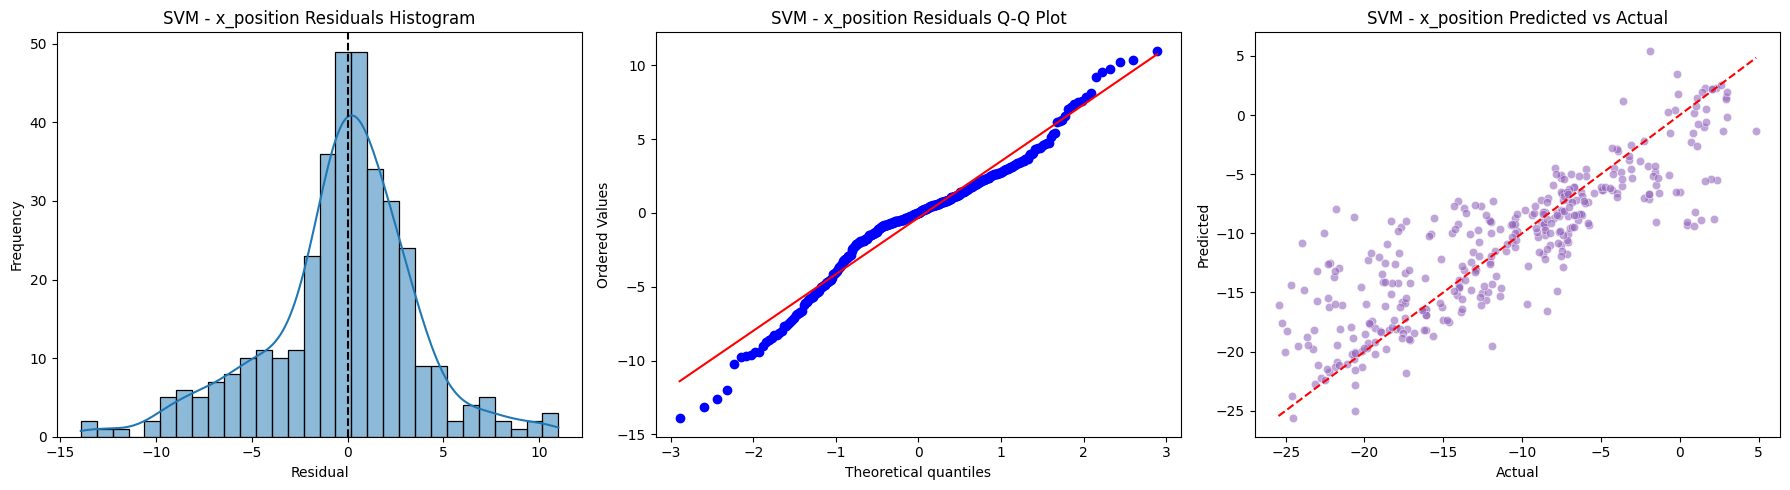

        Model: SVM - x_position
MSE: 15.1635 (95% CI: [-73.2769, -49.3155])
RMSE: 3.8940
MAE: 2.7820
R^2: 0.7250
Residual Mean: -0.3197, Residual Std: 3.8809
Shapiro-Wilk Test p-value: 0.0000 (normality rejected)


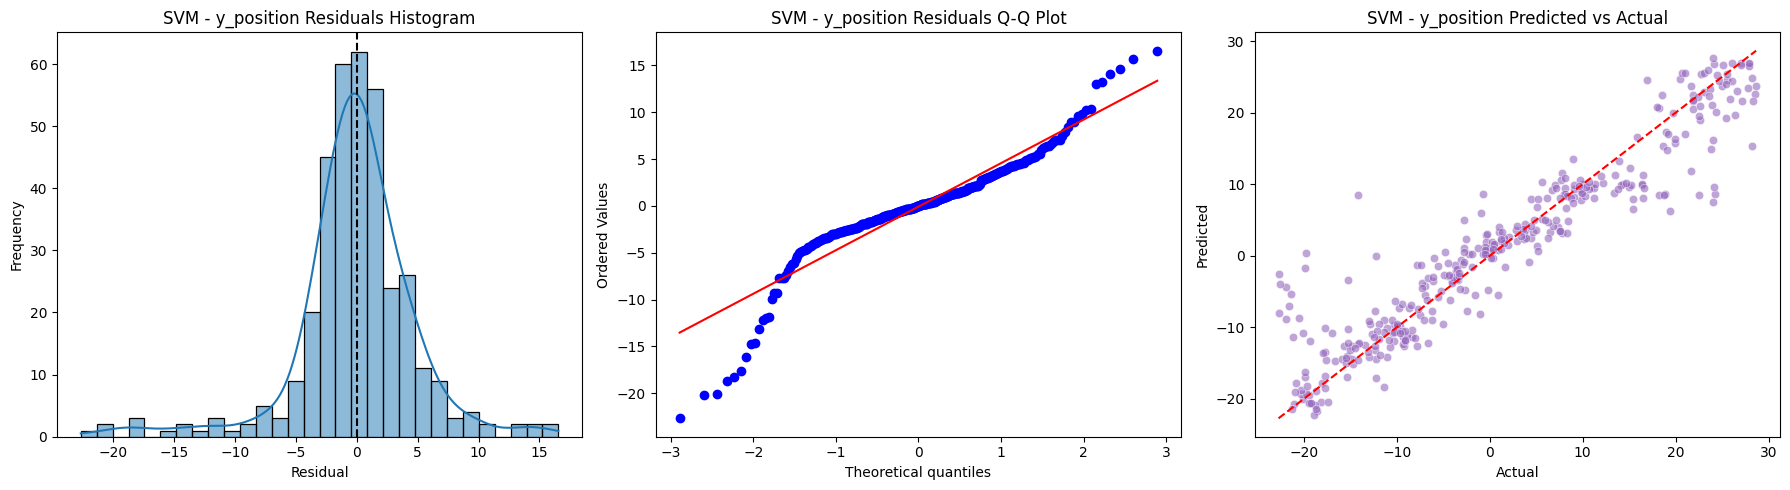

        Model: SVM - y_position
MSE: 23.9435 (95% CI: [-370.8403, -277.1449])
RMSE: 4.8932
MAE: 3.1985
R^2: 0.8846
Residual Mean: -0.0880, Residual Std: 4.8924
Shapiro-Wilk Test p-value: 0.0000 (normality rejected)


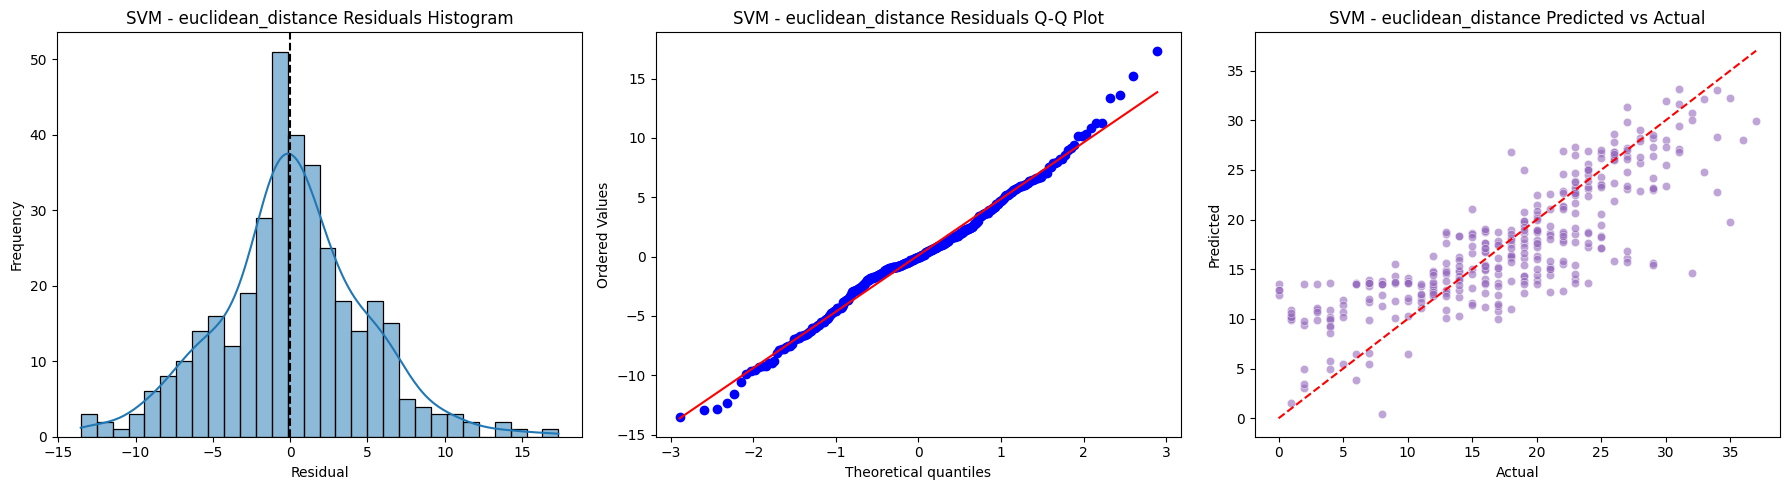

        Model: SVM - euclidean_distance
MSE: 22.5586 (95% CI: [-75.7091, -46.3814])
RMSE: 4.7496
MAE: 3.5633
R^2: 0.6712
Residual Mean: 0.1096, Residual Std: 4.7483
Shapiro-Wilk Test p-value: 0.0096 (normality rejected)


In [9]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

svm_models = {}
svm_preds = {}
svm_best_params = {}

svm_params = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf']
}

for target_name, (y_train_target, y_test_target) in targets.items():
    svm = SVR()
    svm_grid = GridSearchCV(svm, svm_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    svm_grid.fit(X_train, y_train_target)
    y_pred_svm = svm_grid.predict(X_test)

    print(f"\nSVM Evaluation for {target_name}:")
    print('=' * 30)
    print("Best Params:", svm_grid.best_params_)
    print("Test MSE:", mean_squared_error(y_test_target, y_pred_svm))
    print("Test MAE:", mean_absolute_error(y_test_target, y_pred_svm))
    print("Test R2:", r2_score(y_test_target, y_pred_svm))
    print(f'='*30)
    print()

    svm_models[target_name] = svm_grid.best_estimator_
    svm_preds[target_name] = (y_test_target, y_pred_svm)
    svm_best_params[target_name] = svm_grid.best_params_

for target_name, (y_train_target, y_test_target) in targets.items():
    model_analytics(svm_preds[target_name][0], svm_preds[target_name][1], 'SVM - ' + target_name)

### Random Forest Regression

Random Forest Regression uses an ensemble of decision trees trained on bootstrapped samples with random feature selection:

- Each tree predicts a value for the input.
- The final prediction is the average of all tree predictions.
- Reduces overfitting compared to individual trees.
- Handles nonlinear relationships and interactions automatically.



Random Forest Evaluation for x_position:
Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Test MSE: 10.36857752903024
Test MAE: 2.1853238292611015
Test R2: 0.8119730096658644


Random Forest Evaluation for y_position:
Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Test MSE: 5.78658764917296
Test MAE: 1.6755128210235237
Test R2: 0.972116651360654


Random Forest Evaluation for euclidean_distance:
Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Test MSE: 9.598975120114957
Test MAE: 2.254429977246158
Test R2: 0.860082097904041



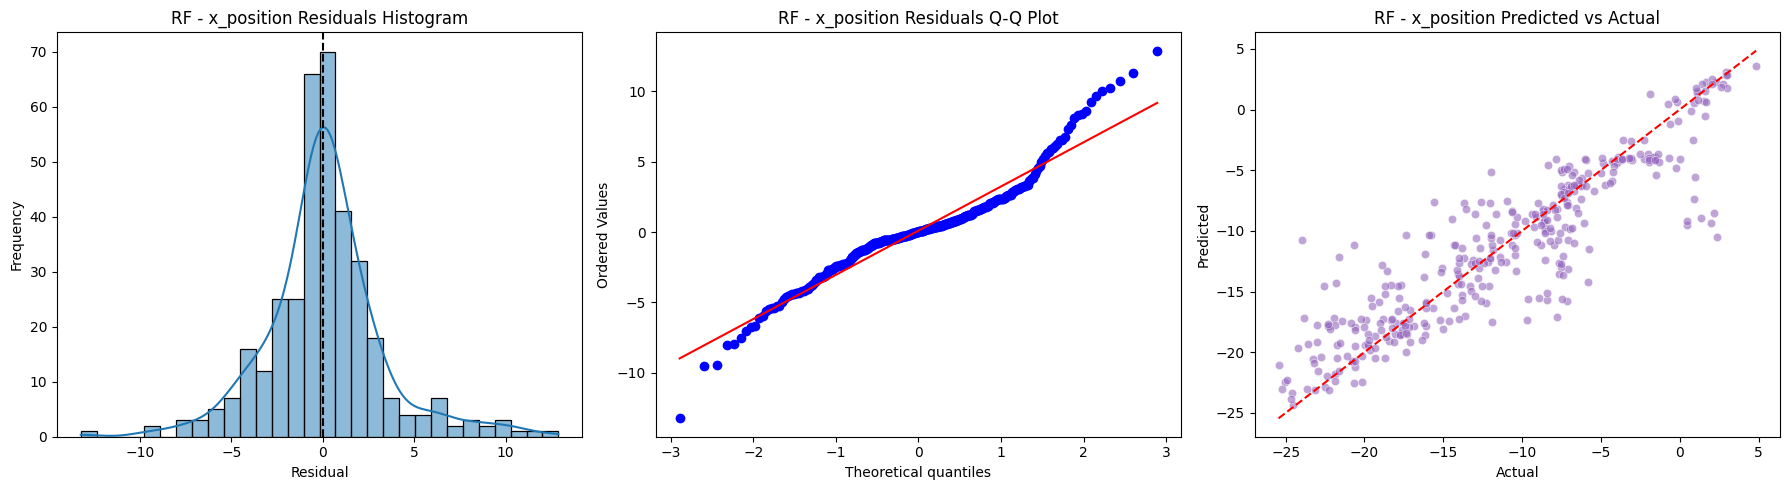

        Model: RF - x_position
MSE: 10.3686 (95% CI: [-89.8223, -64.5160])
RMSE: 3.2200
MAE: 2.1853
R^2: 0.8120
Residual Mean: 0.0995, Residual Std: 3.2185
Shapiro-Wilk Test p-value: 0.0000 (normality rejected)


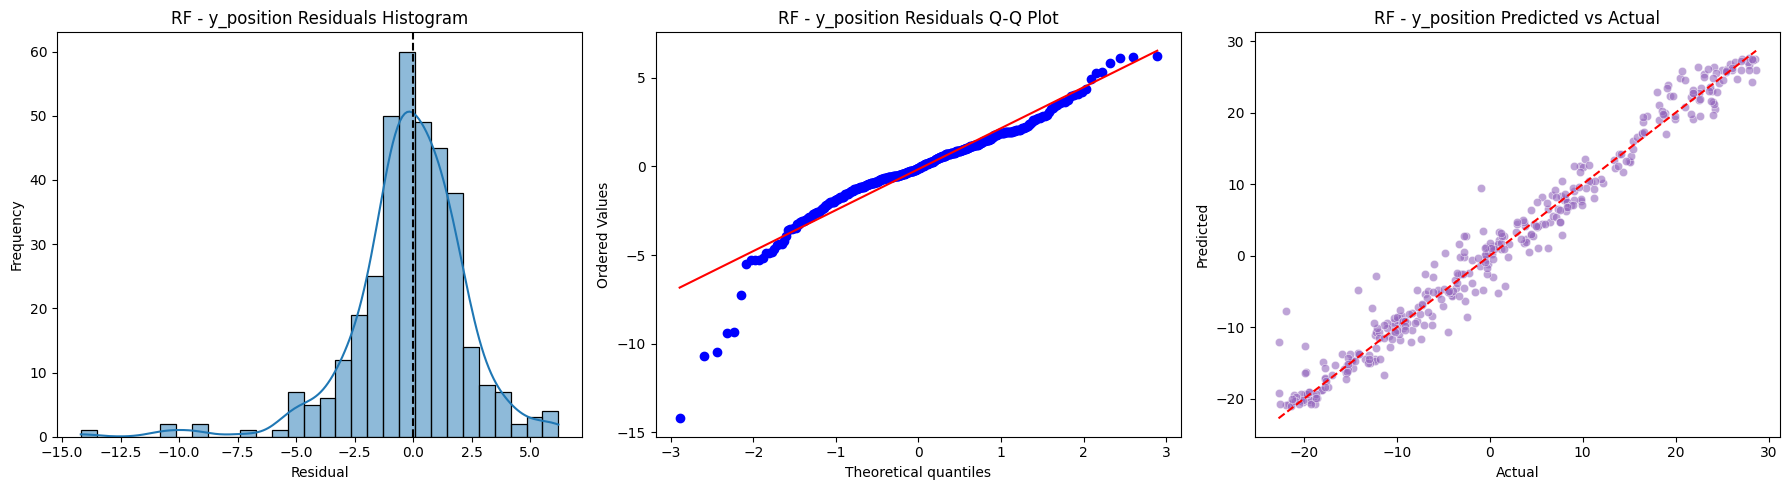

        Model: RF - y_position
MSE: 5.7866 (95% CI: [-452.6824, -349.9729])
RMSE: 2.4055
MAE: 1.6755
R^2: 0.9721
Residual Mean: -0.1554, Residual Std: 2.4005
Shapiro-Wilk Test p-value: 0.0000 (normality rejected)


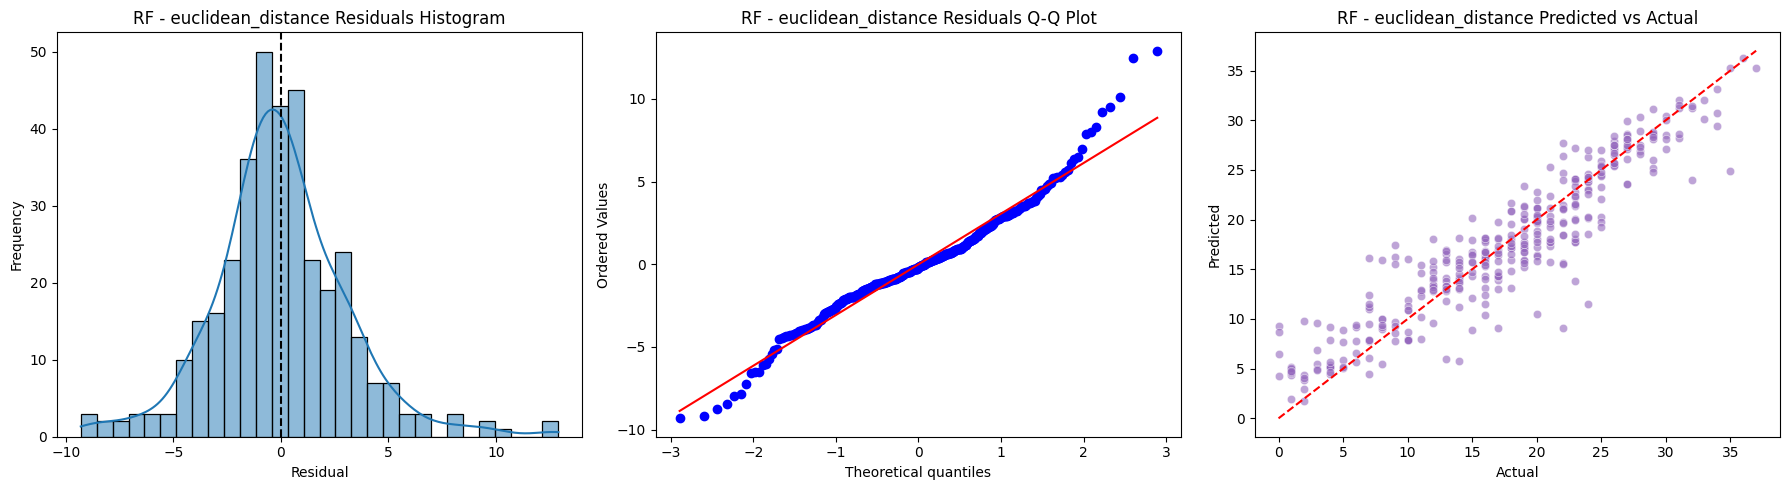

        Model: RF - euclidean_distance
MSE: 9.5990 (95% CI: [-123.8213, -88.5508])
RMSE: 3.0982
MAE: 2.2544
R^2: 0.8601
Residual Mean: -0.0045, Residual Std: 3.0982
Shapiro-Wilk Test p-value: 0.0000 (normality rejected)


In [10]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_models = {}
rf_preds = {}
rf_best_params = {}

rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

for target_name, (y_train_target, y_test_target) in targets.items():
    rf = RandomForestRegressor(random_state=42)
    rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    rf_grid.fit(X_train, y_train_target)
    y_pred_rf = rf_grid.predict(X_test)

    print(f"\nRandom Forest Evaluation for {target_name}:")
    print('=' * 30)
    print("Best Params:", rf_grid.best_params_)
    print("Test MSE:", mean_squared_error(y_test_target, y_pred_rf))
    print("Test MAE:", mean_absolute_error(y_test_target, y_pred_rf))
    print("Test R2:", r2_score(y_test_target, y_pred_rf))
    print(f'='*30)
    print()

    rf_models[target_name] = rf_grid.best_estimator_
    rf_preds[target_name] = (y_test_target, y_pred_rf)
    rf_best_params[target_name] = rf_grid.best_params_

for target_name, (y_train_target, y_test_target) in targets.items():
    model_analytics(rf_preds[target_name][0], rf_preds[target_name][1], 'RF - ' + target_name)

### Gradient Boosting Machine (GBM) Regression

GBM builds an additive model by sequentially fitting decision trees to the residual errors of prior models using gradient descent on a loss function:

$$
F_M(\mathbf{x}) = \sum_{m=1}^M \gamma_m h_m(\mathbf{x})
$$

where:  
- $h_m(\mathbf{x})$ is the $m$-th weak learner (decision tree).  
- $\gamma_m$ is the step size or learning rate.  
- Each $h_m$ is fit to the negative gradient of the loss function at iteration $m$.  
- Combines weak learners to improve predictive accuracy.  



GBM Evaluation for x_position:
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}
Test MSE: 10.85631808875126
Test MAE: 2.346423510058704
Test R2: 0.8031281715719732


GBM Evaluation for y_position:
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Test MSE: 6.960060462778261
Test MAE: 1.7716970085039443
Test R2: 0.9664621355105004


GBM Evaluation for euclidean_distance:
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}
Test MSE: 10.416083535983981
Test MAE: 2.4227167982065216
Test R2: 0.8481716497673678



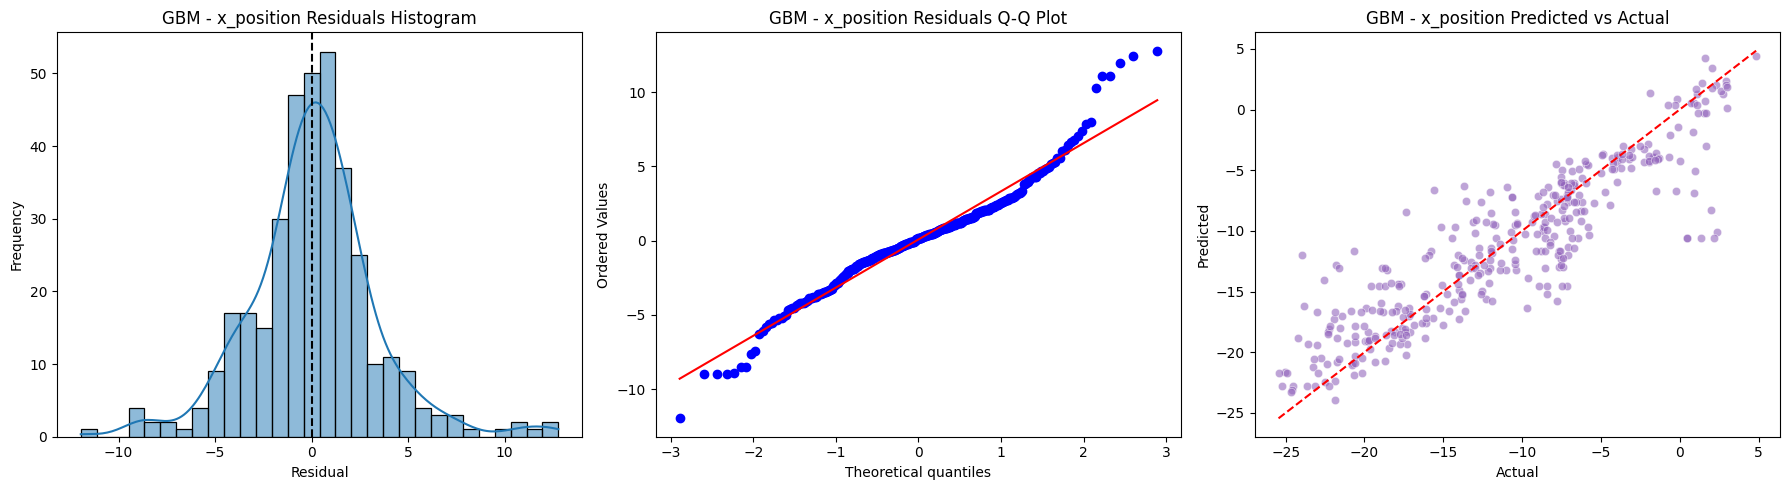

        Model: GBM - x_position
MSE: 10.8563 (95% CI: [-87.0241, -62.3505])
RMSE: 3.2949
MAE: 2.3464
R^2: 0.8031
Residual Mean: 0.0830, Residual Std: 3.2938
Shapiro-Wilk Test p-value: 0.0000 (normality rejected)


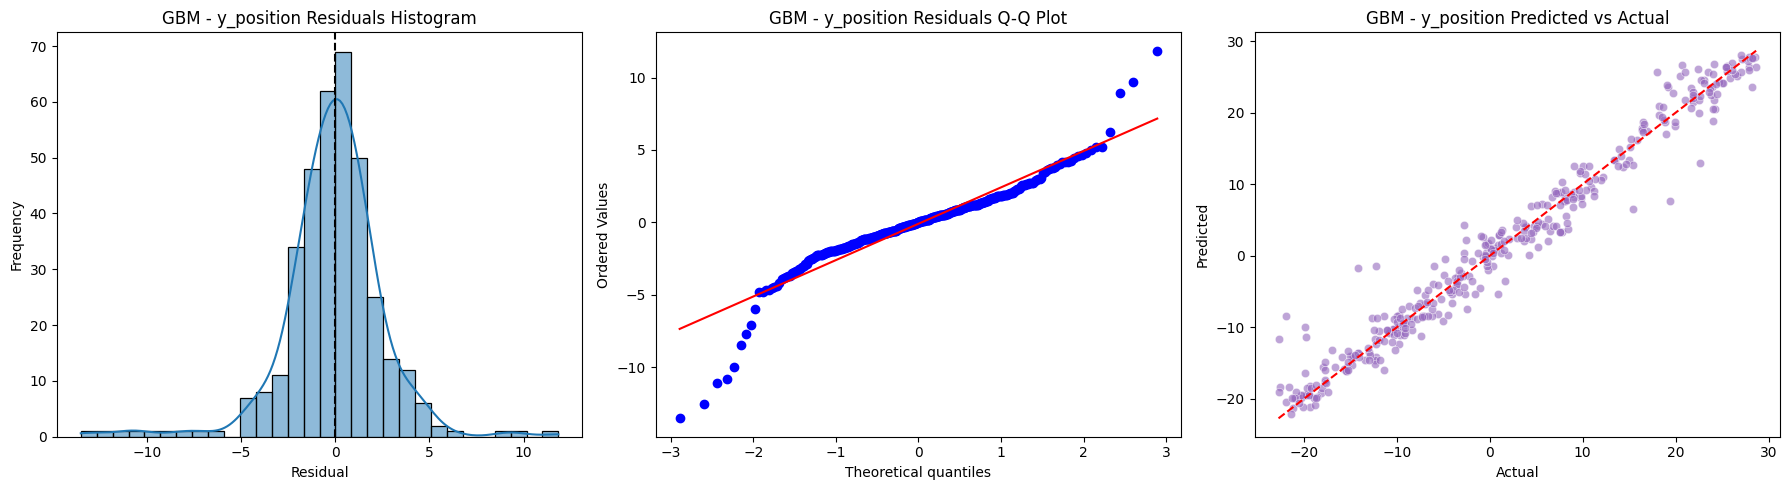

        Model: GBM - y_position
MSE: 6.9601 (95% CI: [-449.4549, -340.9101])
RMSE: 2.6382
MAE: 1.7717
R^2: 0.9665
Residual Mean: -0.0918, Residual Std: 2.6366
Shapiro-Wilk Test p-value: 0.0000 (normality rejected)


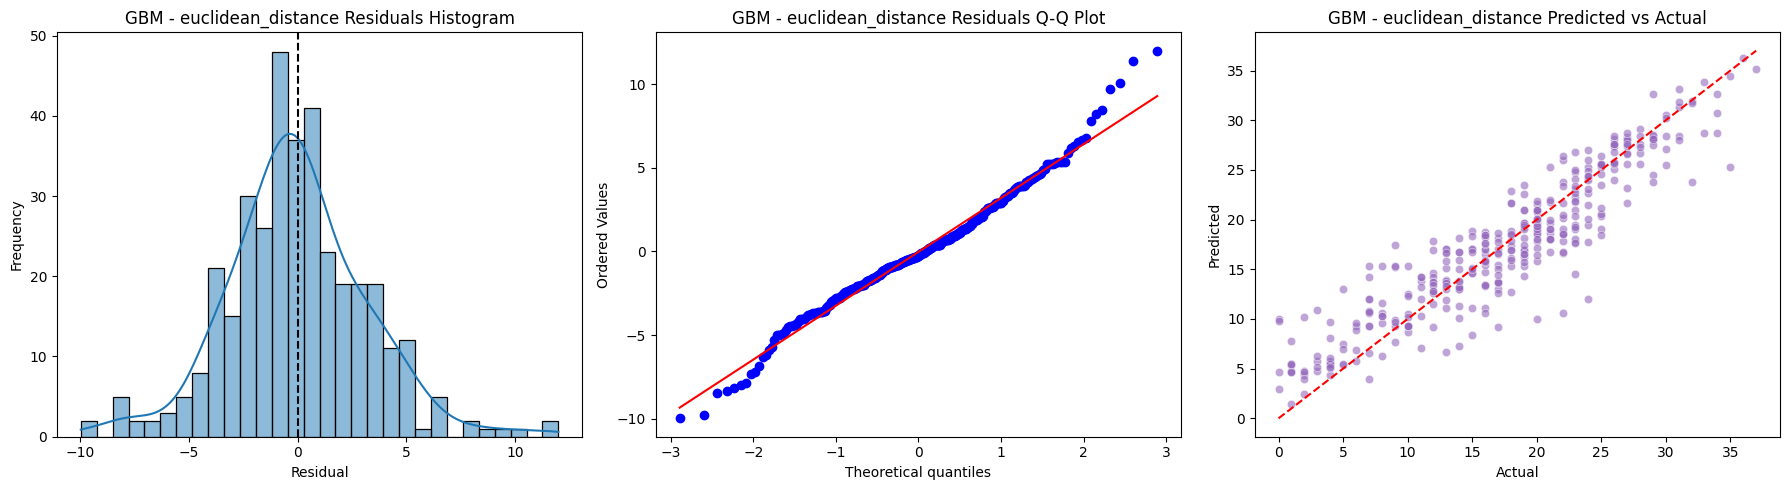

        Model: GBM - euclidean_distance
MSE: 10.4161 (95% CI: [-116.6158, -84.8657])
RMSE: 3.2274
MAE: 2.4227
R^2: 0.8482
Residual Mean: -0.0216, Residual Std: 3.2273
Shapiro-Wilk Test p-value: 0.0004 (normality rejected)


In [11]:
from sklearn.ensemble import GradientBoostingRegressor

gbm_models = {}
gbm_preds = {}
gbm_best_params = {}

gbm_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

for target_name, (y_train_target, y_test_target) in targets.items():
    gbm = GradientBoostingRegressor(random_state=42)
    gbm_grid = GridSearchCV(gbm, gbm_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    gbm_grid.fit(X_train, y_train_target)
    y_pred_gbm = gbm_grid.predict(X_test)

    print(f"\nGBM Evaluation for {target_name}:")
    print('=' * 30)
    print("Best Params:", gbm_grid.best_params_)
    print("Test MSE:", mean_squared_error(y_test_target, y_pred_gbm))
    print("Test MAE:", mean_absolute_error(y_test_target, y_pred_gbm))
    print("Test R2:", r2_score(y_test_target, y_pred_gbm))
    print('=' * 30)
    print()

    gbm_models[target_name] = gbm_grid.best_estimator_
    gbm_preds[target_name] = (y_test_target, y_pred_gbm)
    gbm_best_params[target_name] = gbm_grid.best_params_

for target_name, (y_train_target, y_test_target) in targets.items():
    model_analytics(gbm_preds[target_name][0], gbm_preds[target_name][1], 'GBM - ' + target_name)

### Extreme Gradient Boosting (XGBoost) Regression

XGBoost is an optimized implementation of gradient boosting with enhancements for speed and performance.

- Uses gradient boosting framework to combine weak learners (trees).  
- Includes regularization to reduce overfitting.  


XGBoost Evaluation for x_position:
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Test MSE: 10.77168044137154
Test MAE: 2.2716416309197416
Test R2: 0.8046630168350977

XGBoost Evaluation for y_position:
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Test MSE: 7.007241848868538
Test MAE: 1.7968271428813125
Test R2: 0.9662347864893842

XGBoost Evaluation for euclidean_distance:
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Test MSE: 10.368267113568399
Test MAE: 2.360541900109056
Test R2: 0.8488686380839748


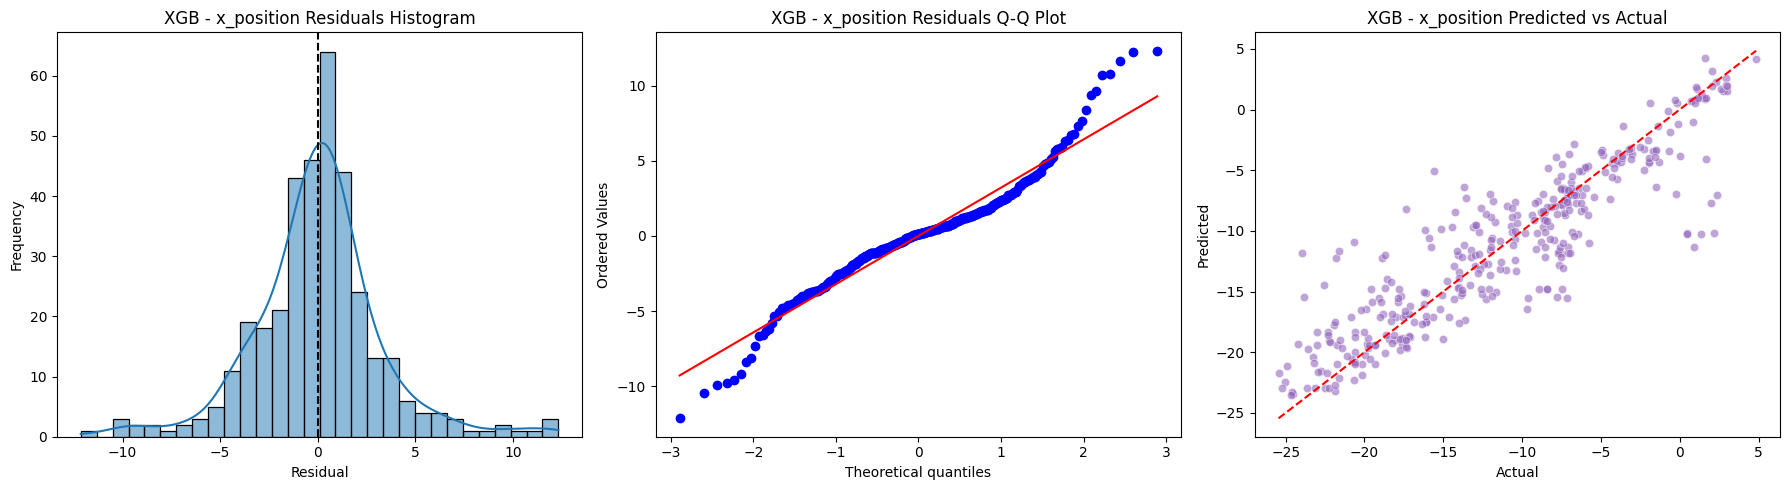

        Model: XGB - x_position
MSE: 10.7717 (95% CI: [-90.0885, -64.1179])
RMSE: 3.2820
MAE: 2.2716
R^2: 0.8047
Residual Mean: -0.0015, Residual Std: 3.2820
Shapiro-Wilk Test p-value: 0.0000 (normality rejected)


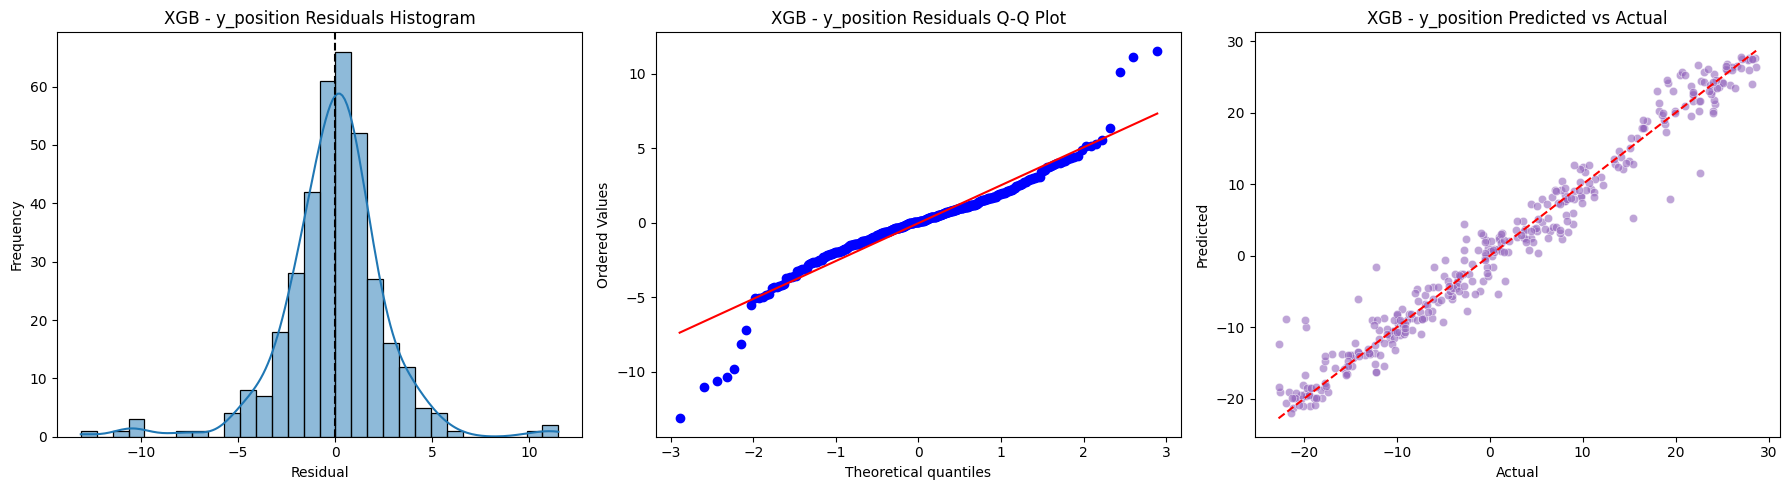

        Model: XGB - y_position
MSE: 7.0072 (95% CI: [-445.9848, -344.0558])
RMSE: 2.6471
MAE: 1.7968
R^2: 0.9662
Residual Mean: -0.0314, Residual Std: 2.6469
Shapiro-Wilk Test p-value: 0.0000 (normality rejected)


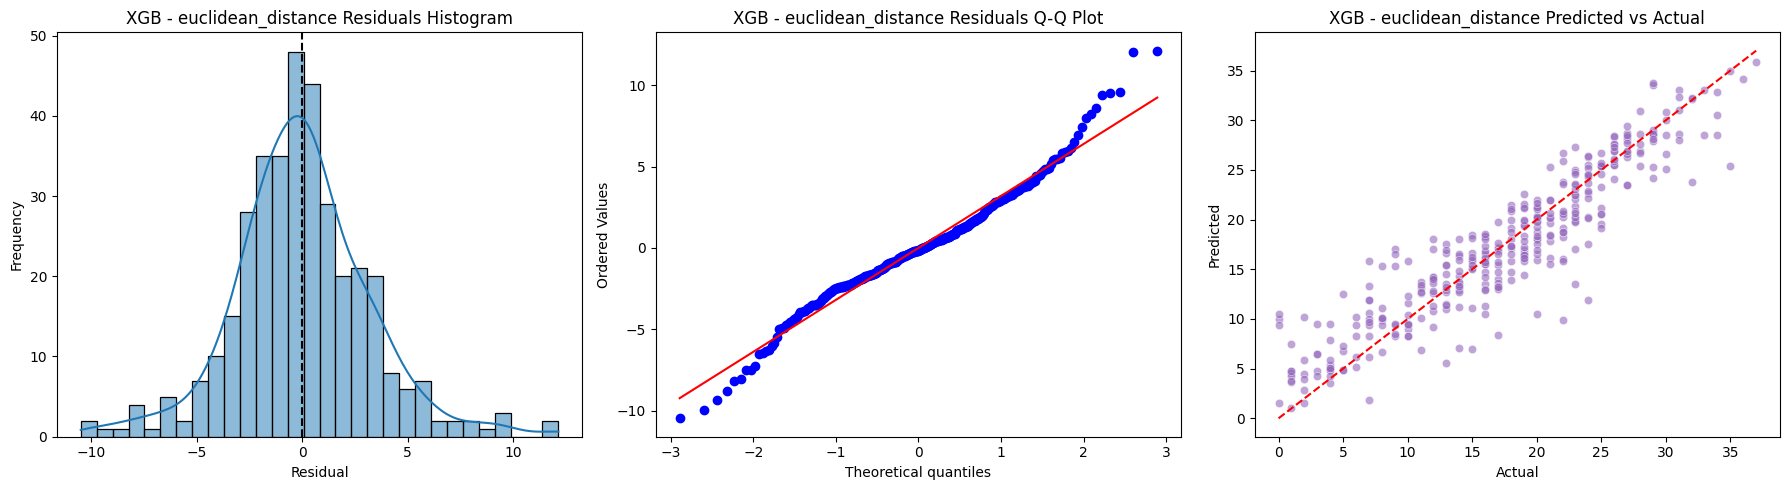

        Model: XGB - euclidean_distance
MSE: 10.3683 (95% CI: [-121.7766, -87.1810])
RMSE: 3.2200
MAE: 2.3605
R^2: 0.8489
Residual Mean: 0.0027, Residual Std: 3.2200
Shapiro-Wilk Test p-value: 0.0000 (normality rejected)


In [12]:
from xgboost import XGBRegressor

xgb_models = {}
xgb_preds = {}
xgb_best_params = {}

xgb_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

for target_name, (y_train_target, y_test_target) in targets.items():
    xgb = XGBRegressor(random_state=42, verbosity=0)
    xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    xgb_grid.fit(X_train, y_train_target)
    y_pred_xgb = xgb_grid.predict(X_test)

    print(f"\nXGBoost Evaluation for {target_name}:")
    print('=' * 30)
    print("Best Params:", xgb_grid.best_params_)
    print("Test MSE:", mean_squared_error(y_test_target, y_pred_xgb))
    print("Test MAE:", mean_absolute_error(y_test_target, y_pred_xgb))
    print("Test R2:", r2_score(y_test_target, y_pred_xgb))
    print('=' * 30)

    xgb_models[target_name] = xgb_grid.best_estimator_
    xgb_preds[target_name] = (y_test_target, y_pred_xgb)
    xgb_best_params[target_name] = xgb_grid.best_params_

for target_name, (y_train_target, y_test_target) in targets.items():
    model_analytics(xgb_preds[target_name][0], xgb_preds[target_name][1], 'XGB - ' + target_name)

### Multi-Layer Perceptron (MLP) Regression

MLP is a feedforward neural network with multiple layers of neurons. The output is computed as:

$$
\mathbf{a}^{(l)} = \sigma \left( \mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)} \right)
$$

where:  
- $\mathbf{a}^{(l)}$ is the activation vector at layer $l$.  
- $\mathbf{W}^{(l)}$ and $\mathbf{b}^{(l)}$ are the weight matrix and bias vector of layer $l$.  
- $\sigma$ is a nonlinear activation function (e.g., ReLU, sigmoid).  
- For the input layer, $\mathbf{a}^{(0)} = \mathbf{x}$ (input features).  
- The output layer produces the prediction $\hat{y}$ for regression tasks.



MLP Evaluation for x_position:
Best Params: {'activation': 'tanh', 'alpha': 0.001, 'early_stopping': True, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.01, 'max_iter': 1000}
Test MSE: 19.323562898167378
Test MAE: 3.3354415632256216
Test R2: 0.6495805365681051


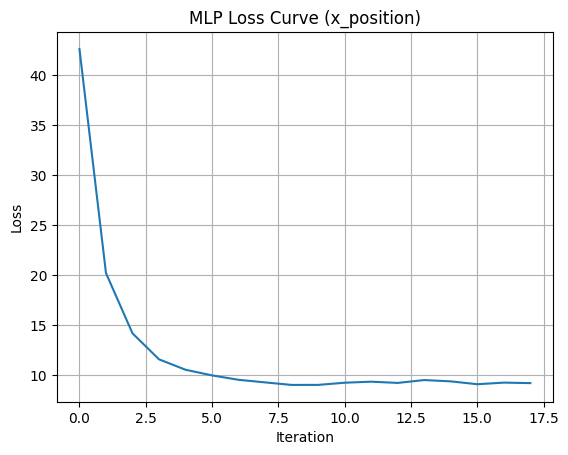


MLP Evaluation for y_position:
Best Params: {'activation': 'tanh', 'alpha': 0.001, 'early_stopping': True, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.001, 'max_iter': 1000}
Test MSE: 19.811989813960356
Test MAE: 2.977562461054222
Test R2: 0.9045336124303268


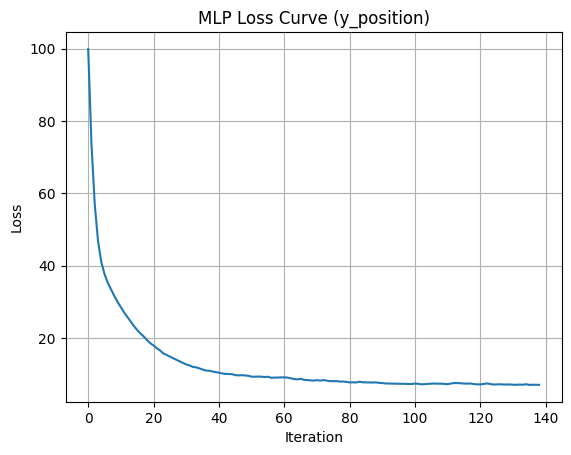


MLP Evaluation for euclidean_distance:
Best Params: {'activation': 'tanh', 'alpha': 0.001, 'early_stopping': True, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.01, 'max_iter': 1000}
Test MSE: 18.05072507178829
Test MAE: 3.2154607773244783
Test R2: 0.73688653718218


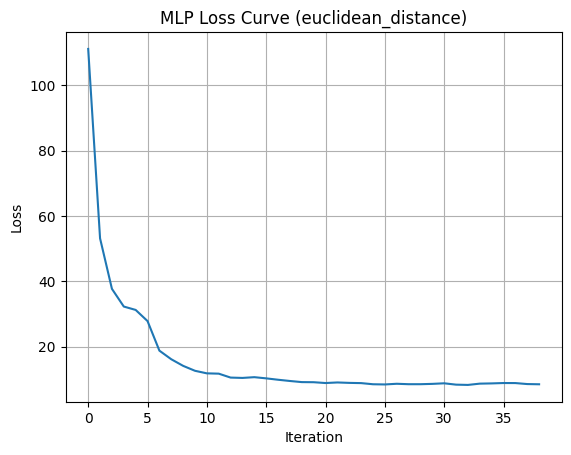

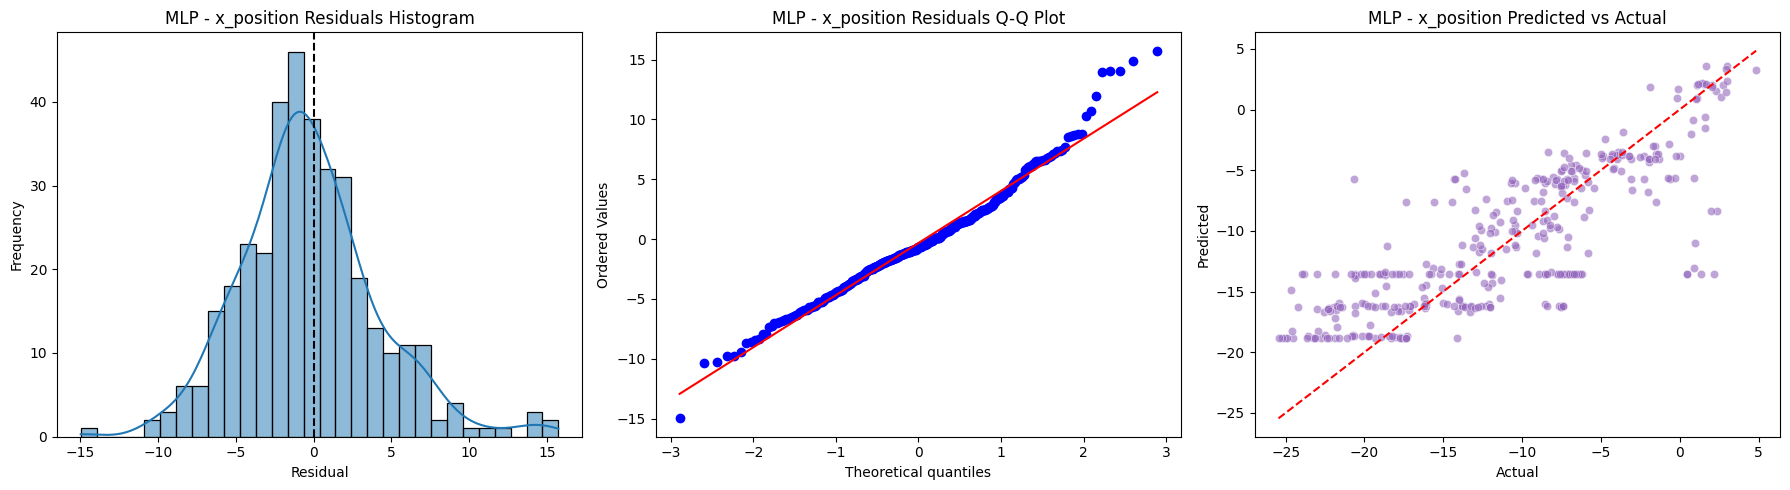

        Model: MLP - x_position
MSE: 19.3236 (95% CI: [-63.4089, -40.6187])
RMSE: 4.3959
MAE: 3.3354
R^2: 0.6496
Residual Mean: -0.3254, Residual Std: 4.3838
Shapiro-Wilk Test p-value: 0.0000 (normality rejected)


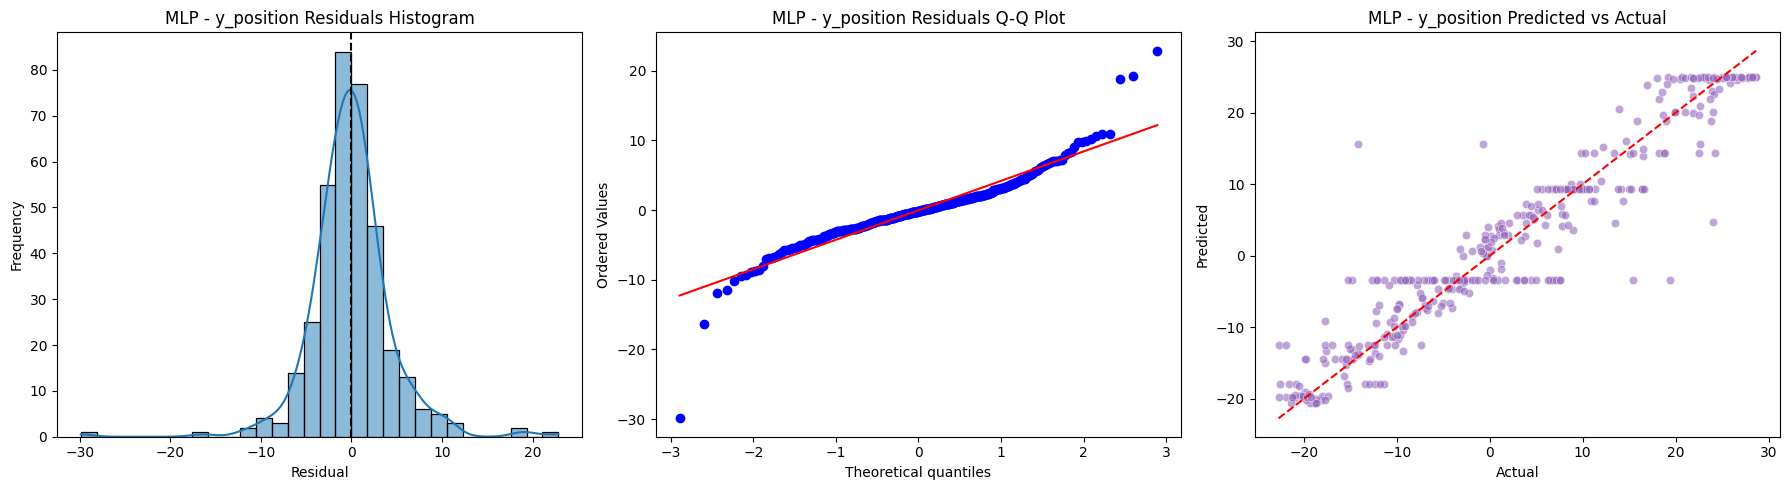

        Model: MLP - y_position
MSE: 19.8120 (95% CI: [-408.7545, -306.9351])
RMSE: 4.4511
MAE: 2.9776
R^2: 0.9045
Residual Mean: -0.0447, Residual Std: 4.4508
Shapiro-Wilk Test p-value: 0.0000 (normality rejected)


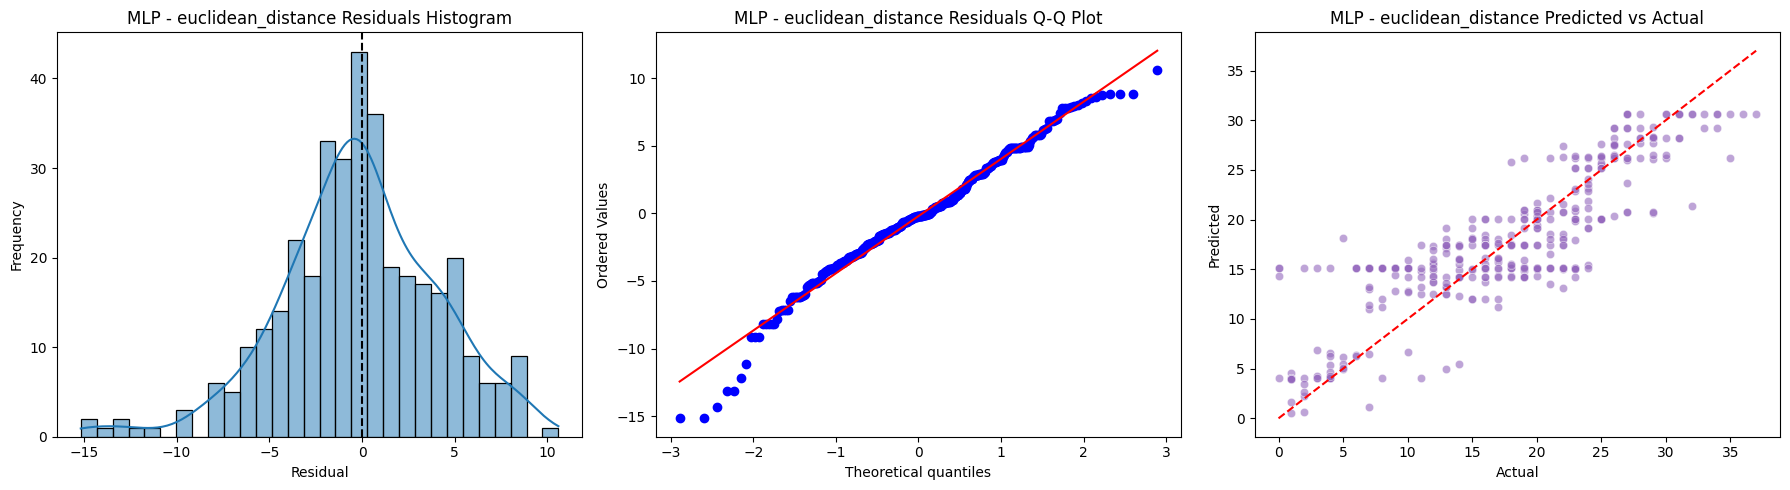

        Model: MLP - euclidean_distance
MSE: 18.0507 (95% CI: [-98.8648, -65.3394])
RMSE: 4.2486
MAE: 3.2155
R^2: 0.7369
Residual Mean: -0.2007, Residual Std: 4.2439
Shapiro-Wilk Test p-value: 0.0002 (normality rejected)


In [13]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV

mlp_models = {}
mlp_preds = {}
mlp_loss_curves = {}
mlp_best_params = {}

mlp_params = {
    'hidden_layer_sizes': [(256, 128, 64), (256, 128, 64, 32)],
    'activation': ['relu', 'tanh'],
    'alpha': [1e-5, 1e-4, 1e-3],
    'learning_rate_init': [0.001, 0.01],
    'early_stopping': [True],
    'max_iter': [1000]
}

for target_name, (y_train_target, y_test_target) in targets.items():
    mlp = MLPRegressor(
        random_state=42,
        verbose=False,
        early_stopping=True,
        validation_fraction=0.2,
        n_iter_no_change=10
    )
    mlp_grid = GridSearchCV(mlp, mlp_params, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    mlp_grid.fit(X_train, y_train_target)
    y_pred_mlp = mlp_grid.predict(X_test)

    print(f"\nMLP Evaluation for {target_name}:")
    print('=' * 30)
    print("Best Params:", mlp_grid.best_params_)
    print("Test MSE:", mean_squared_error(y_test_target, y_pred_mlp))
    print("Test MAE:", mean_absolute_error(y_test_target, y_pred_mlp))
    print("Test R2:", r2_score(y_test_target, y_pred_mlp))
    print('=' * 30)

    mlp_models[target_name] = mlp_grid.best_estimator_
    mlp_preds[target_name] = (y_test_target, y_pred_mlp)
    mlp_loss_curves[target_name] = mlp_grid.best_estimator_.loss_curve_
    
    plt.plot(mlp_loss_curves[target_name])
    plt.title(f"MLP Loss Curve ({target_name})")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

for target_name, (y_train_target, y_test_target) in targets.items():
    model_analytics(mlp_preds[target_name][0], mlp_preds[target_name][1], 'MLP - ' + target_name)

In [14]:
# Peformance Comparison between models

import plotly.graph_objects as go
from plotly.subplots import make_subplots

comparison_targets = {
    'Euclidean Distance': 'euclidean_distance',
    'X Position': 'x_position',
    'Y Position': 'y_position'
}

for comp_name, target_key in comparison_targets.items():
    print(f"\n=== Model Performance Comparison: {comp_name} ===")
    y_test = targets[target_key][1]
    y_preds = [
        poly_preds[target_key][1],
        gam_preds[target_key][1],
        svm_preds[target_key][1],
        rf_preds[target_key][1],
        gbm_preds[target_key][1],
        xgb_preds[target_key][1],
        mlp_preds[target_key][1]
    ]
    model_names = [
        "Polynomial Regression",
        "GAM",
        "SVM",
        "Random Forest",
        "GBM",
        "XGBoost",
        "MLP"
    ]

    metrics = {
        "MSE": [],
        "RMSE": [],
        "MAE": [],
        "R^2": []
    }

    for y_pred in y_preds:
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        metrics["MSE"].append(mse)
        metrics["RMSE"].append(rmse)
        metrics["MAE"].append(mae)
        metrics["R^2"].append(r2)

    fig = make_subplots(rows=2, cols=2, subplot_titles=list(metrics.keys()))
    row_col = [(1, 1), (1, 2), (2, 1), (2, 2)]

    for i, (metric, values) in enumerate(metrics.items()):
        row, col = row_col[i]
        fig.add_trace(
            go.Bar(x=model_names, y=values, name=metric),
            row=row, col=col
        )
        fig.update_yaxes(title_text=metric, row=row, col=col)

    fig.update_layout(
        height=700,
        width=900,
        title_text=f"Model Performance Comparison: {comp_name}",
        showlegend=False,
        template="plotly_white"
    )

    fig.show()



=== Model Performance Comparison: Euclidean Distance ===



=== Model Performance Comparison: X Position ===



=== Model Performance Comparison: Y Position ===
